# Análise dos dados 

### Bibliotecas

In [ ]:
import folium
import pandas as pd
from geopy import distance
import numpy as np
import matplotlib.pyplot as plt
import math
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, f1_score, recall_score
from sklearn.model_selection import KFold
from sklearn.neural_network import MLPClassifier
import time

### Mapping LOS/NLOS

In [ ]:

df_complete_LOS = pd.read_csv("LOS_data.csv") # LOS positioning data
df_complete_NLOS = pd.read_csv("NLOS_data.csv") # NLOS positioning data

# Centralized the map on the average latitude and longitude of the data points
latitude_central = df_complete_LOS['Latitude'].mean()
longitude_central = df_complete_LOS['Longitude'].mean()
map = folium.Map(location=[latitude_central, longitude_central], zoom_start=30, max_zoom=200)

# Adding markers for each set of coordinates in the DataFrame
df_complete_LOS = df_complete_LOS.assign(sight=1)      # Add column with sight equal to 1
df_complete_NLOS = df_complete_NLOS.assign(sight=0)    # Add column with sight equal to 0
GW_pos = [-21.77886349497853, -43.37347360887864]   # latitude/longitude of Gateway

folium.CircleMarker(location=[GW_pos[0],GW_pos[1]],color='black').add_to(map)  # Marker for the Gateway on the map

for index, row in df_complete_LOS.iterrows():
    folium.CircleMarker(location=[row['Latitude'], row['Longitude']],color='blue').add_to(map)     # Marker for the LOS points on the map

    
for index, row in df_complete_NLOS.iterrows():
    folium.CircleMarker(location=[row['Latitude'], row['Longitude']],color='red').add_to(map)      # Marker for the NLOS points on the map
    
map.save('complete_map.html')  # Complete map


Concatenate the LOS and NLOS data into a single DataFrame

In [ ]:
df_final = pd.concat([df_complete_LOS, df_complete_NLOS])   # Concatenate the LOS and NLOS data into a single DataFrame
df_final = df_final.assign(Distance=0) # Column Distance


### Add the height of the building and the length of the antenna to the initial altitude of the Gateway

In [ ]:
height_ini = 923.3       # Altitude GW
height_building = 13   # Height of the building where the Gateway is located
lenght_antenna = 1.8     # Length of the antenna used in the measurements


height_ini = height_ini + height_building + lenght_antenna


for index, row in df_final.iterrows():
  lat_final = row['Latitude']
  longi_final = row['Longitude']
  alt_final = row['Altitude']
  flat_distance = distance.distance((GW_pos[0], GW_pos[1]), (lat_final,longi_final)).meters
  euclidian_distance = math.sqrt(flat_distance**2 + (alt_final - height_ini)**2)
  df_final.at[index,'Distance'] = euclidian_distance




In [5]:
df_final

,Time,GPS Time,id,Latitude,Longitude,Altitude,GPS Precision,# Satellites,ED RSSI,GW RSSI,Visada,Distância
0,18:44:32,21:44:24,33,-21.777797,-43.374139,918.7,1,14,-104,-85,1,226.487957
1,18:44:40,21:44:32,34,-21.778067,-43.374374,921.1,1,14,-101,-97,1,226.487957
2,18:45:13,21:45:04,38,-21.779387,-43.374631,922.3,1,14,-88,-87,1,226.486135
3,18:45:21,21:45:13,39,-21.779459,-43.374125,923.9,1,14,-91,-84,1,226.487448
4,18:45:29,21:45:21,40,-21.779385,-43.373685,924.6,1,14,-88,-76,1,226.481052
...,...,...,...,...,...,...,...,...,...,...,...,...
567,16:53:39,19:53:31,471,-21.772752,-43.366115,895.7,1,13,-99,-99,0,1019.325734
568,16:53:47,19:53:39,472,-21.772753,-43.366199,895.6,1,13,-101,-102,0,1012.733837
569,16:53:55,19:53:47,473,-21.772771,-43.366277,895.8,1,13,-112,-103,0,1005.381778
570,16:54:03,19:53:55,474,-21.772808,-43.366326,896.1,1,12,-100,-100,0,998.838692


### Correlation matrix analysis

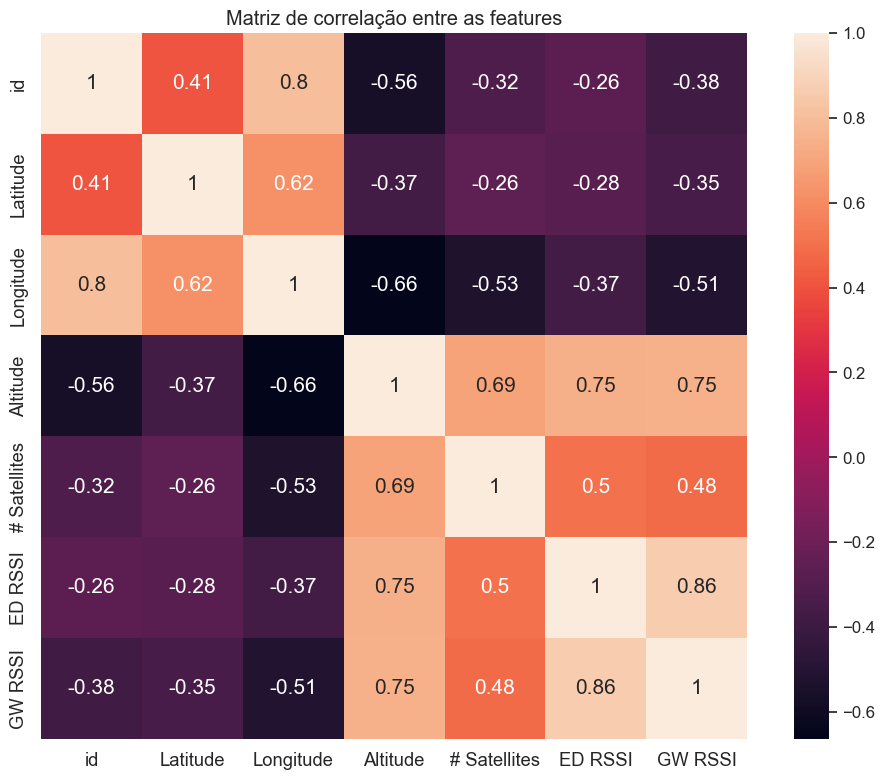

In [ ]:
# Correlation matrix between the features
plt.subplots(figsize=(10, 8))
plt.title('Matriz de correlação entre as features')
X = df_final.loc[:,['Time','GPS Time','id','Latitude','Longitude','Altitude',
                    '# Satellites', 'ED RSSI', 'GW RSSI', ]]
sns.set_theme(font_scale=1.1)
sns.heatmap(X.corr(), vmax=1.0, square=True,annot=True, annot_kws={"size": 15})

plt.savefig('fig1 - Correlation Matrix')
plt.tight_layout()
plt.show()

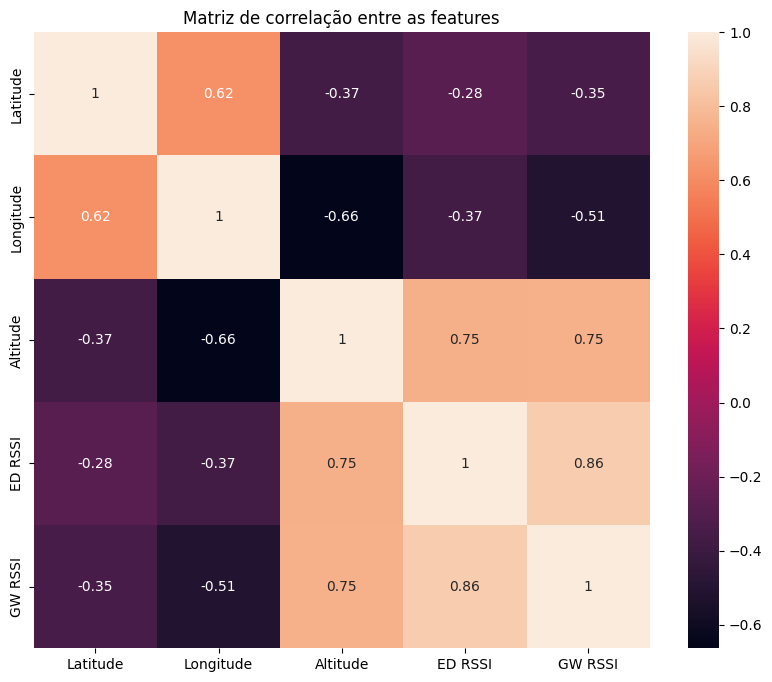

In [ ]:
# Correlation matrix between the features
plt.subplots(figsize=(10, 8))
plt.title('Matriz de correlação entre as features')
X = df_final.loc[:,['Latitude','Longitude','Altitude',
                    'ED RSSI', 'GW RSSI']]

sns.heatmap(X.corr(), vmax=1.0, square=True,annot=True)

plt.savefig('fig2 - Correlation Matrix after Feature Selection')
plt.show()

### Pre processing the data for the machine learning models


In [ ]:
X = df_final.loc[:,['Latitude','Longitude','Altitude',
                    'ED RSSI']]


y = df_final.loc[:,['Sight',]]

### KNN (K Nearest Neighbors)

In [ ]:
kf = KFold(n_splits=10, shuffle=True, random_state=42)
i = 0
score_list = []
precision_list = []
recall_list = []
f1_list = []
y = np.ravel(np.array(y))


for train_index, test_index in (kf.split(X)):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        Y_train, Y_test  = y[train_index], y[test_index]

        scaler = MinMaxScaler()
        # scaler.fit(X_train)
        X_train_normalized = scaler.fit_transform(X_train)

        # scaler.fit(X_test)
        X_test_normalized = scaler.transform(X_test)

        knn = KNeighborsClassifier(n_neighbors = 4, weights='uniform').fit(X_train_normalized, Y_train)

        y_pred = knn.predict(X_test_normalized)
        score = knn.score(X_test_normalized, Y_test)
        precision = precision_score(Y_test, y_pred)
        recall = recall_score(Y_test, y_pred)
        f1 = f1_score(Y_test, y_pred)

        # print(f"Score: {score}")
        # print(f"Precision: {precision}")
        # print(f"Recall: {recall}")
        # print(f"F-1 score: {f1}")
        i = i + 1
        score_list.append(score)
        precision_list.append(precision)
        recall_list.append(recall)
        f1_list.append(f1)


score_mean = np.mean(np.array(score_list))
score_std = np.std(np.array(score_list))

precision_mean = np.mean(np.array(precision_list))
precision_std = np.std(np.array(precision_list))

recall_mean = np.mean(np.array(recall_list))
recall_std = np.std(np.array(recall_list))

f1_mean = np.mean(np.array(f1_list))
f1_std = np.std(np.array(f1_list))


print("--------------\n (KNN)")
print(f"avg Score: ({(score_mean * 100):.2f}) +/- ({(score_std * 100):.2f})")
print(f"avg Precisão: {(precision_mean * 100):.2f} +/- ({(precision_std * 100):.2f})")
print(f"avg Recall: {(recall_mean * 100):.2f} +/- ({(recall_std * 100):.2f})")
print(f"avg F1: {(f1_mean * 100):.2f} +/- ({(f1_std * 100):.2f})")

### MLP (Multi-Layer Perceptron)

In [ ]:
kf = KFold(n_splits=10, shuffle=True, random_state=42)
i = 0
score_list = []
precision_list = []
recall_list = []
f1_list = []
y = np.ravel(np.array(y))


for train_index, test_index in (kf.split(X)):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        Y_train, Y_test  = y[train_index], y[test_index]

        scaler = MinMaxScaler()
        # scaler.fit(X_train)
        X_train_normalized = scaler.fit_transform(X_train)

        # scaler.fit(X_test)
        X_test_normalized = scaler.transform(X_test)

        mlp_classifier = MLPClassifier(hidden_layer_sizes=(5), activation='logistic',
                             random_state=42, max_iter=6000, alpha=0.0001,
                             verbose=False,
                             solver='lbfgs').fit(X_train_normalized, Y_train)

        y_pred = mlp_classifier.predict(X_test_normalized)
        score = mlp_classifier.score(X_test_normalized, Y_test)
        precision = precision_score(Y_test, y_pred)
        recall = recall_score(Y_test, y_pred)
        f1 = f1_score(Y_test, y_pred)

        i = i + 1
        score_list.append(score)
        precision_list.append(precision)
        recall_list.append(recall)
        f1_list.append(f1)

score_mean = np.mean(np.array(score_list))
score_std = np.std(np.array(score_list))

precision_mean = np.mean(np.array(precision_list))
precision_std = np.std(np.array(precision_list))

recall_mean = np.mean(np.array(recall_list))
recall_std = np.std(np.array(recall_list))

f1_mean = np.mean(np.array(f1_list))
f1_std = np.std(np.array(f1_list))


print("--------------\n (MLP)")
print(f"avg Score: ({(score_mean * 100):.2f}) +/- ({(score_std * 100):.2f})")
print(f"avg Precisão: {(precision_mean * 100):.2f} +/- ({(precision_std * 100):.2f})")
print(f"avg Recall: {(recall_mean * 100):.2f} +/- ({(recall_std * 100):.2f})")
print(f"avg F1: {(f1_mean * 100):.2f} +/- ({(f1_std * 100):.2f})")


### SVM RBF (Suport Vector Machine Radius Base Forward)

In [ ]:
kf = KFold(n_splits=10, shuffle=True, random_state=42)
i = 0
score_list = []
precision_list = []
recall_list = []
f1_list = []
y = np.ravel(np.array(y))


for train_index, test_index in (kf.split(X)):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        Y_train, Y_test  = y[train_index], y[test_index]


        scaler = MinMaxScaler()
        X_train_normalized = scaler.fit_transform(X_train)

        X_test_normalized = scaler.transform(X_test)
        svc_kbf = SVC(C = 1.0, kernel = 'rbf').fit(X_train_normalized, Y_train)

        score = svc_kbf.score(X_test_normalized, Y_test)
        y_pred = svc_kbf.predict(X_test_normalized)
        precision = precision_score(Y_test, y_pred)
        recall = recall_score(Y_test, y_pred)
        f1 = f1_score(Y_test, y_pred)

        i = i + 1
        score_list.append(score)
        precision_list.append(precision)
        recall_list.append(recall)
        f1_list.append(f1)

score_mean = np.mean(np.array(score_list))
score_std = np.std(np.array(score_list))

precision_mean = np.mean(np.array(precision_list))
precision_std = np.std(np.array(precision_list))

recall_mean = np.mean(np.array(recall_list))
recall_std = np.std(np.array(recall_list))

f1_mean = np.mean(np.array(f1_list))
f1_std = np.std(np.array(f1_list))


print("--------------\n SVM")
print(f"avg Score: ({(score_mean * 100):.2f}) +/- ({(score_std * 100):.2f})")
print(f"avg Precisão: {(precision_mean * 100):.2f} +/- ({(precision_std * 100):.2f})")
print(f"avg Recall: {(recall_mean * 100):.2f} +/- ({(recall_std * 100):.2f})")
print(f"avg F1: {(f1_mean * 100):.2f} +/- ({(f1_std * 100):.2f})")


In [ ]:
Cs = np.linspace(1.0, 10, 10)
kernels = ['poly', 'rbf', 'sigmoid']
coefs0 = np.linspace(0, 50, 10)
tols =[0.0001, 0.001, 0.01]
gammas = ['scale', 'auto']

kf = KFold(n_splits=10, shuffle=True, random_state=42)
i = 0
classification_time_list = []
score_list = []
precision_list = []
recall_list = []
f1_list = []
y = np.ravel(np.array(y))
best_precision = 0
best_parameters_svm = []

with open('analise_results_svm.txt', 'a') as results:
    results.write("--- Modelo SVM --- \n")

results.close()
for C in Cs:
    for kernel in kernels:
        for coef0 in coefs0:
           for tol in tols:
                for gamma in gammas:
                    for train_index, test_index in (kf.split(X)):
                        if(kernel == 'rbf'):
                            break
                        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
                        Y_train, Y_test  = y[train_index], y[test_index]

                        start_time = time.time()
                        scaler = MinMaxScaler()
                        X_train_normalized = scaler.fit_transform(X_train)

                        X_test_normalized = scaler.transform(X_test)
                        svc_kbf = SVC(C=C, kernel=kernel, coef0=coef0, tol=tol, gamma=gamma).fit(X_train_normalized, Y_train)

                        end_time = time.time()
                        
                        classification_time = end_time - start_time
                        y_pred = svc_kbf.predict(X_test_normalized)
                        score = svc_kbf.score(X_test_normalized, Y_test)
                        precision = precision_score(Y_test, y_pred)
                        recall = recall_score(Y_test, y_pred)
                        f1 = f1_score(Y_test, y_pred)

                        i = i + 1
                        classification_time_list.append(classification_time)
                        score_list.append(score)
                        precision_list.append(precision)
                        recall_list.append(recall)
                        f1_list.append(f1)

                    classification_time_mean = np.mean(np.array(classification_time_list))
                    classification_time_std = np.std(np.array(classification_time_list))

                    score_mean = np.mean(np.array(score_list))
                    score_std = np.std(np.array(score_list))

                    precision_mean = np.mean(np.array(precision_list))
                    precision_std = np.std(np.array(precision_list))

                    recall_mean = np.mean(np.array(recall_list))
                    recall_std = np.std(np.array(recall_list))

                    f1_mean = np.mean(np.array(f1_list))
                    f1_std = np.std(np.array(f1_list))

                    classification_time_list.clear()
                    score_list.clear()
                    precision_list.clear()
                    recall_list.clear()
                    f1_list.clear()

                    # print(f"--------------\n SVM {C, kernel, coef0, tol, gamma} ")
                    # print(f"Score: ({(score_mean * 100):.2f}) +/- ({(score_std * 100):.2f})")
                    # print(f"Precisão média: {(precision_mean * 100):.2f} +/- ({(precision_std * 100):.2f})")
                    # print(f"Recall médio: {(recall_mean * 100):.2f} +/- ({(recall_std * 100):.2f})")
                    # print(f"F1 médio: {(f1_mean * 100):.2f} +/- ({(f1_std * 100):.2f})")

                    with open('analise_results_svm.txt', 'a') as results:
                        results.write(f"Para C = {C}, kernel = {kernel}, coef0 = {coef0}, tol = {tol}, gamma = {gamma}\n")
                        results.write(f"Score: ({(score_mean * 100):.2f}) +/- ({(score_std * 100):.2f}), Precisão média: {(precision_mean * 100):.2f} +/- ({(precision_std * 100):.2f}), Recall médio: {(recall_mean * 100):.2f} +/- ({(recall_std * 100):.2f}), F1 médio: {(f1_mean * 100):.2f} +/- ({(f1_std * 100):.2f}), Tempo médio (ms): {(classification_time_mean * 1000):.3f} +/- ({(classification_time_std *1000):.3f})\n")
                        results.close()

                    if ((precision_mean + precision_std <= 1.0) and (best_precision <= precision_mean)):
                        best_precision = precision_mean
                        best_parameters_svm = [C, kernel, coef0, tol, gamma]

    



### RF (Random Forest)

In [ ]:
kf = KFold(n_splits=10, shuffle=True, random_state=42)
i = 0
score_list = []
precision_list = []
recall_list = []
f1_list = []
y = np.ravel(np.array(y))


for train_index, test_index in (kf.split(X)):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        Y_train, Y_test  = y[train_index], y[test_index]


        scaler = MinMaxScaler()
        # scaler.fit(X_train)
        X_train_normalized = scaler.fit_transform(X_train)

        # scaler.fit(X_test)
        X_test_normalized = scaler.transform(X_test)
        rfc = RandomForestClassifier(n_estimators=100, criterion='gini', max_depth=None, min_samples_split=2,
                                     min_samples_leaf=1, min_weight_fraction_leaf=0.0, max_features='sqrt',
                                     max_leaf_nodes=None, min_impurity_decrease=0.0, bootstrap=True, oob_score=False,
                                     n_jobs=None, random_state=None, verbose=0, warm_start=False, class_weight=None,
                                     ccp_alpha=0.0, max_samples=None).fit(X_train_normalized, Y_train)
        score = rfc.score(X_test_normalized, Y_test)
        y_pred = rfc.predict(X_test_normalized)
        precision = precision_score(Y_test, y_pred)
        recall = recall_score(Y_test, y_pred)
        f1 = f1_score(Y_test, y_pred)

        i = i + 1
        score_list.append(score)
        precision_list.append(precision)
        recall_list.append(recall)
        f1_list.append(f1)

score_mean = np.mean(np.array(score_list))
score_std = np.std(np.array(score_list))

precision_mean = np.mean(np.array(precision_list))
precision_std = np.std(np.array(precision_list))

recall_mean = np.mean(np.array(recall_list))
recall_std = np.std(np.array(recall_list))

f1_mean = np.mean(np.array(f1_list))
f1_std = np.std(np.array(f1_list))


print("--------------\n Random Forest")
print(f"avg Score: ({(score_mean * 100):.2f}) +/- ({(score_std * 100):.2f})")
print(f"avg Precisão: {(precision_mean * 100):.2f} +/- ({(precision_std * 100):.2f})")
print(f"avg Recall: {(recall_mean * 100):.2f} +/- ({(recall_std * 100):.2f})")
print(f"avg F1: {(f1_mean * 100):.2f} +/- ({(f1_std * 100):.2f})")
